In [1]:
import warnings

import dask.dataframe as dd
import pyarrow.parquet as pq
import pyarrow as pa

import pandas as pd
import numpy as np
from fastparquet import write

import pickle

from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from scipy.stats import norm

import json
import gc
import glob
from pathlib import Path
import time

## Loading and dataset column splitting into categories

In [2]:
df_centrooeste = pd.read_csv("centrooeste_natan.txt")
df_centrooeste.head(3)

/tmp/ipykernel_134475/3906899911.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_centrooeste = pd.read_csv("centrooeste_natan.txt")


,Bairros.SP,Bairros.Fortaleza,Bairros.RJ,Causa.Afastamento.1,Causa.Afastamento.2,Causa.Afastamento.3,Motivo.Desligamento,CBO.Ocupação.2002,CNAE.2.0.Classe,CNAE.95.Classe,...,Vl.Rem.Junho.SC,Vl.Rem.Julho.SC,Vl.Rem.Agosto.SC,Vl.Rem.Setembro.SC,Vl.Rem.Outubro.SC,Vl.Rem.Novembro.SC,Ano.Chegada.Brasil,Ind.Trab.Intermitente,Ind.Trab.Parcial,Estado
0,9997,9997,9997,40,99,99,11,514225,68226,70327,...,1412.0,1412.0,0.0,0.0,0.0,0.0,1198,0,0,Campo Grande
1,9997,9997,9997,99,99,99,11,711210,2306,999,...,2250.0,2250.0,2250.0,150.0,0.0,0.0,1198,0,0,Campo Grande
2,9997,9997,9997,99,99,99,60,517420,47440,52442,...,0.0,0.0,0.0,0.0,0.0,0.0,1198,0,0,Campo Grande


In [3]:
df_centrooeste.columns

Index(['Bairros.SP', 'Bairros.Fortaleza', 'Bairros.RJ', 'Causa.Afastamento.1',
       'Causa.Afastamento.2', 'Causa.Afastamento.3', 'Motivo.Desligamento',
       'CBO.Ocupação.2002', 'CNAE.2.0.Classe', 'CNAE.95.Classe',
       'Distritos.SP', 'Vínculo.Ativo.31.12', 'Faixa.Etária',
       'Faixa.Hora.Contrat', 'Faixa.Remun.Dezem..SM.',
       'Faixa.Remun.Média..SM.', 'Faixa.Tempo.Emprego',
       'Escolaridade.após.2005', 'Qtd.Hora.Contr', 'Idade',
       'Ind.CEI.Vinculado', 'Ind.Simples', 'Mês.Admissão', 'Mês.Desligamento',
       'Mun.Trab', 'Município', 'Nacionalidade', 'Natureza.Jurídica',
       'Ind.Portador.Defic', 'Qtd.Dias.Afastamento', 'Raça.Cor',
       'Regiões.Adm.DF', 'Vl.Remun.Dezembro.Nom', 'Vl.Remun.Dezembro..SM.',
       'Vl.Remun.Média.Nom', 'Vl.Remun.Média..SM.', 'CNAE.2.0.Subclasse',
       'Sexo.Trabalhador', 'Tamanho.Estabelecimento', 'Tempo.Emprego',
       'Tipo.Admissão', 'Tipo.Estab', 'Tipo.Estab.1', 'Tipo.Defic',
       'Tipo.Vínculo', 'IBGE.Subsetor', 'Vl.

In [4]:
demographic_variables = ["Idade", "Faixa.Etária", "Sexo.Trabalhador", "Raça.Cor", "Escolaridade.após.2005",
                         "Nacionalidade", "Ano.Chegada.Brasil", "Ind.Portador.Defic", "Tipo.Defic"]
company_variables = ["Município", "Mun.Trab", "Estado", "CNAE.2.0.Classe", "CNAE.95.Classe", "CNAE.2.0.Subclasse",
                     "Natureza.Jurídica", "Tamanho.Estabelecimento", "Tipo.Estab", "Tipo.Estab.1", "IBGE.Subsetor",
                     "Ind.Simples", "Ind.CEI.Vinculado"]
vinculo_variables = ["CBO.Ocupação.2002", "Tipo.Vínculo", "Tipo.Admissão", "Vínculo.Ativo.31.12",
                     "Mês.Admissão", "Mês.Desligamento", "Motivo.Desligamento", "Tempo.Emprego", "Faixa.Tempo.Emprego",
                     "Qtd.Hora.Contr", "Faixa.Hora.Contrat", "Ind.Trab.Intermitente", "Ind.Trab.Parcial"]
remuneracao_variables = ["Vl.Remun.Média.Nom", "Vl.Remun.Média..SM.",
                         "Vl.Rem.Janeiro.SC", "Vl.Rem.Fevereiro.SC", 
                         "Vl.Rem.Março.SC", "Vl.Rem.Abril.SC",
                         "Vl.Rem.Maio.SC", "Vl.Rem.Junho.SC",
                         "Vl.Rem.Julho.SC", "Vl.Rem.Agosto.SC",
                         "Vl.Rem.Setembro.SC", "Vl.Rem.Outubro.SC",
                         "Vl.Rem.Novembro.SC", "Vl.Remun.Dezembro.Nom"]
desligamento_variables = ["Causa.Afastamento.1", "Causa.Afastamento.2", "Causa.Afastamento.3",
                          "Qtd.Dias.Afastamento"]
geographic_variables = ["Distritos.SP", "Bairros.SP", "Bairros.Fortaleza", "Bairros.RJ", "Regiões.Adm.DF"]

df_centrooeste_demographic = df_centrooeste.loc[:, demographic_variables]
df_centrooeste_company = df_centrooeste.loc[:, company_variables]
df_centrooeste_vinculo = df_centrooeste.loc[:, vinculo_variables]
df_centrooeste_remuneracao = df_centrooeste.loc[:, remuneracao_variables]
df_centrooeste_desligamento = df_centrooeste.loc[:, desligamento_variables]
df_centrooeste_geographic = df_centrooeste.loc[:, geographic_variables]

display( df_centrooeste_demographic.head(3) )
display( df_centrooeste_company.head(3) )
display( df_centrooeste_vinculo.head(3) )
display( df_centrooeste_remuneracao.head(3) )
display( df_centrooeste_desligamento.head(3) )
display( df_centrooeste_geographic.head(3) )

,Idade,Faixa.Etária,Sexo.Trabalhador,Raça.Cor,Escolaridade.após.2005,Nacionalidade,Ano.Chegada.Brasil,Ind.Portador.Defic,Tipo.Defic
0,35,5,1,2,1,10,1198,1,4
1,50,7,1,8,1,10,1198,0,0
2,48,6,1,8,1,10,1198,0,0


,Município,Mun.Trab,Estado,CNAE.2.0.Classe,CNAE.95.Classe,CNAE.2.0.Subclasse,Natureza.Jurídica,Tamanho.Estabelecimento,Tipo.Estab,Tipo.Estab.1,IBGE.Subsetor,Ind.Simples,Ind.CEI.Vinculado
0,500270,500270,Campo Grande,68226,70327,6822600,2062,4,1,CNPJ,19,9,1
1,500270,500270,Campo Grande,2306,999,230600,2062,4,1,CNPJ,19,9,9
2,500270,500270,Campo Grande,47440,52442,4744001,2062,5,1,CNPJ,16,9,9


,CBO.Ocupação.2002,Tipo.Vínculo,Tipo.Admissão,Vínculo.Ativo.31.12,Mês.Admissão,Mês.Desligamento,Motivo.Desligamento,Tempo.Emprego,Faixa.Tempo.Emprego,Qtd.Hora.Contr,Faixa.Hora.Contrat,Ind.Trab.Intermitente,Ind.Trab.Parcial
0,514225,10,0,0,0,7,11,18.0,4,44,6,0,0
1,711210,10,0,0,0,9,11,15.0,4,99,99,0,0
2,517420,10,0,0,0,3,60,187.3,8,44,6,0,0


,Vl.Remun.Média.Nom,Vl.Remun.Média..SM.,Vl.Rem.Janeiro.SC,Vl.Rem.Fevereiro.SC,Vl.Rem.Março.SC,Vl.Rem.Abril.SC,Vl.Rem.Maio.SC,Vl.Rem.Junho.SC,Vl.Rem.Julho.SC,Vl.Rem.Agosto.SC,Vl.Rem.Setembro.SC,Vl.Rem.Outubro.SC,Vl.Rem.Novembro.SC,Vl.Remun.Dezembro.Nom
0,1390.00,1.05,1335.00,1335.00,1412.00,1412.0,1412.0,1412.0,1412.0,0.0,0.0,0.0,0.0,0.0
1,2256.25,1.72,2300.00,2250.00,2250.00,2250.0,2250.0,2250.0,2250.0,2250.0,150.0,0.0,0.0,0.0
2,1947.27,1.49,1808.18,1808.18,2225.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,Causa.Afastamento.1,Causa.Afastamento.2,Causa.Afastamento.3,Qtd.Dias.Afastamento
0,40,99,99,1
1,99,99,99,0
2,99,99,99,0


,Distritos.SP,Bairros.SP,Bairros.Fortaleza,Bairros.RJ,Regiões.Adm.DF
0,9997,9997,9997,9997,9997
1,9997,9997,9997,9997,9997
2,9997,9997,9997,9997,9997


In [5]:
len(demographic_variables) + len(company_variables) + len(vinculo_variables) + len(remuneracao_variables) + len(desligamento_variables) + len(geographic_variables)

58

In [6]:
used_vars = np.concatenate([ demographic_variables, company_variables, vinculo_variables ,remuneracao_variables, desligamento_variables, geographic_variables ])
df_centrooeste.columns[~np.isin(df_centrooeste.columns, used_vars)]

Index(['Faixa.Remun.Dezem..SM.', 'Faixa.Remun.Média..SM.',
       'Vl.Remun.Dezembro..SM.'],
      dtype='object')

In [7]:
df_centrooeste_demographic.columns = ["idade", "faixa_etaria", "sexo", "raca", "escolaridade", "nacionalidade", "ano_chegada", "deficiente", "tipo_deficiencia"]
df_centrooeste_demographic

,idade,faixa_etaria,sexo,raca,escolaridade,nacionalidade,ano_chegada,deficiente,tipo_deficiencia
0,35,5,1,2,1,10,1198,1,4
1,50,7,1,8,1,10,1198,0,0
2,48,6,1,8,1,10,1198,0,0
3,33,5,1,9,1,10,1198,0,0
4,73,8,1,8,1,10,1198,0,0
...,...,...,...,...,...,...,...,...,...
2339295,0,99,2,2,11,10,1198,0,0
2339296,0,99,2,2,11,10,1198,0,0
2339297,0,99,2,8,11,10,1198,0,0
2339298,0,99,2,2,11,10,1198,0,0


In [8]:
df_centrooeste_company.columns = ["cod_municipio", "cod_municipio_trabalho", "estado", "cnae_atualizada", "cnae_antiga", "cnae_atualizada_granular", "natureza_juridica",
                                  "tamanho_estabelecimento", "tipo_estabelecimento", "tipo_estabelecimento_1", "ibge_subsetor", "simples_nacional", "cadastro_especifico_inss"]
# Coluna adicional que identifica se o trabalho é realizado na mesma cidade que a sede da empresa.
# Pode ter influência no processo de demissão do funcionário
df_centrooeste_company["trabalho_local_da_sede"] = (df_centrooeste_company["cod_municipio"] == df_centrooeste_company["cod_municipio_trabalho"]).astype("uint8")

df_centrooeste_company.head(3)

,cod_municipio,cod_municipio_trabalho,estado,cnae_atualizada,cnae_antiga,cnae_atualizada_granular,natureza_juridica,tamanho_estabelecimento,tipo_estabelecimento,tipo_estabelecimento_1,ibge_subsetor,simples_nacional,cadastro_especifico_inss,trabalho_local_da_sede
0,500270,500270,Campo Grande,68226,70327,6822600,2062,4,1,CNPJ,19,9,1,1
1,500270,500270,Campo Grande,2306,999,230600,2062,4,1,CNPJ,19,9,9,1
2,500270,500270,Campo Grande,47440,52442,4744001,2062,5,1,CNPJ,16,9,9,1


In [9]:
df_centrooeste_vinculo.columns = ["ocupacao", "tipo_vinculo", "tipo_admissao", "vinculo_ativo_3112",
                                  "mes_admissao", "mes_desligamento", "motivo_desligamento", "tempo_emprego", "faixa_tempo_emprego",
                                  "horas_semanais", "faixa_hora_contratual", "jornada_intermitente", "jornada_parcial"]
df_centrooeste_vinculo.head(3)

,ocupacao,tipo_vinculo,tipo_admissao,vinculo_ativo_3112,mes_admissao,mes_desligamento,motivo_desligamento,tempo_emprego,faixa_tempo_emprego,horas_semanais,faixa_hora_contratual,jornada_intermitente,jornada_parcial
0,514225,10,0,0,0,7,11,18.0,4,44,6,0,0
1,711210,10,0,0,0,9,11,15.0,4,99,99,0,0
2,517420,10,0,0,0,3,60,187.3,8,44,6,0,0


In [10]:
# We note the salary in december is slightly different than the other months, as it may be accounted with the "decimo terceiro"
# And all other new year's gratifications and bonus, which makes it slightly higher than the other months
df_centrooeste_remuneracao.columns = ["remuneracao_media_nominal", "remuneracao_media_sm",
                                      "salario_contribuicao_janeiro", "salario_contribuicao_fevereiro",
                                      "salario_contribuicao_marco", "salario_contribuicao_abril",
                                      "salario_contribuicao_maio", "salario_contribuicao_junho",
                                      "salario_contribuicao_julho", "salario_contribuicao_agosto",
                                      "salario_contribuicao_setembro", "salario_contribuicao_outubro",
                                      "salario_contribuicao_novembro", "salario_contribuicao_dezembro"]
# Filter only columns related to nominal salaries, "decimo terceiro" and "salario de contribuição"
df_centrooeste_remuneracao.head(3)

,remuneracao_media_nominal,remuneracao_media_sm,salario_contribuicao_janeiro,salario_contribuicao_fevereiro,salario_contribuicao_marco,salario_contribuicao_abril,salario_contribuicao_maio,salario_contribuicao_junho,salario_contribuicao_julho,salario_contribuicao_agosto,salario_contribuicao_setembro,salario_contribuicao_outubro,salario_contribuicao_novembro,salario_contribuicao_dezembro
0,1390.00,1.05,1335.00,1335.00,1412.00,1412.0,1412.0,1412.0,1412.0,0.0,0.0,0.0,0.0,0.0
1,2256.25,1.72,2300.00,2250.00,2250.00,2250.0,2250.0,2250.0,2250.0,2250.0,150.0,0.0,0.0,0.0
2,1947.27,1.49,1808.18,1808.18,2225.46,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
def plot_salario_histogram(df, col, limsup = 1.0e4, ax = None):
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

    valid_idx = (df[col] > 0) & (df[col] < limsup)
    sns.histplot(x = col, data = df.loc[valid_idx,:], bins = 200, ax = ax, alpha = 0.5, label = col)

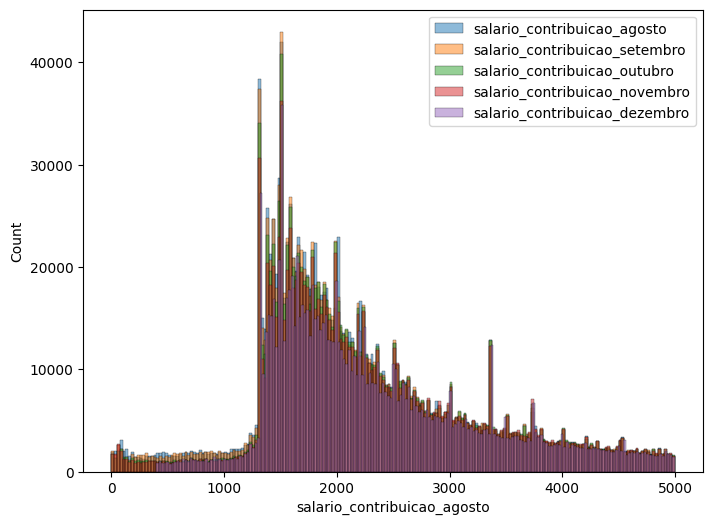

In [12]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

limsup = 5000
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_agosto", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_setembro", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_outubro", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_novembro", limsup = limsup, ax = ax)
plot_salario_histogram(df_centrooeste_remuneracao, "salario_contribuicao_dezembro", limsup = limsup, ax = ax)

ax.legend(loc = "upper right")
plt.show()

Como podemos ver, o mês de dezembro em específico tem um limite inferior em torno de 400. De fato, os valores inferiores a 400 nos demais meses provavelmente dizem respeito a pagamentos proporcionais a dias de trabalho no mês de desligamento, já que são inferiores a um salário. De fato, ao considerar o último mês, mesmo esses valores tender a ter um piso inferior, dado a parcela final do décimo terceiro e possíveis gratificações/abonos de fim de ano.

Ainda assim, vemos um padrão muito similar entre os valores pagos no mês de dezembro e nos demais meses.

In [13]:
df_centrooeste_desligamento.columns = ["causa_afastamento1", "causa_afastamento2", "causa_afastamento3", "qtd_dias_afastamento"]
df_centrooeste_desligamento.head(3)

,causa_afastamento1,causa_afastamento2,causa_afastamento3,qtd_dias_afastamento
0,40,99,99,1
1,99,99,99,0
2,99,99,99,0


In [14]:
df_centrooeste_geographic.columns = ["distrito_sp", "bairro_sp", "bairro_fortaleza", "bairro_rj", "regioes_adm_df"]
df_centrooeste_geographic.head(3)

,distrito_sp,bairro_sp,bairro_fortaleza,bairro_rj,regioes_adm_df
0,9997,9997,9997,9997,9997
1,9997,9997,9997,9997,9997
2,9997,9997,9997,9997,9997


## Merging all columns into a single, clean dataset

#### Demographic

In [15]:
df_centrooeste_demographic.head(2)

,idade,faixa_etaria,sexo,raca,escolaridade,nacionalidade,ano_chegada,deficiente,tipo_deficiencia
0,35,5,1,2,1,10,1198,1,4
1,50,7,1,8,1,10,1198,0,0


In [16]:
df_centrooeste_demographic["ano_chegada"].unique()

array([1198])

#### Company

In [17]:
df_centrooeste_company.head(2)

,cod_municipio,cod_municipio_trabalho,estado,cnae_atualizada,cnae_antiga,cnae_atualizada_granular,natureza_juridica,tamanho_estabelecimento,tipo_estabelecimento,tipo_estabelecimento_1,ibge_subsetor,simples_nacional,cadastro_especifico_inss,trabalho_local_da_sede
0,500270,500270,Campo Grande,68226,70327,6822600,2062,4,1,CNPJ,19,9,1,1
1,500270,500270,Campo Grande,2306,999,230600,2062,4,1,CNPJ,19,9,9,1


É interessante realizarmos a simplificação do Código CNAE das empresas para considerar uma classificação mais geral de suas funções. Para isso, consideramos as 21 classes já previstas pelo IBGE para a atividade de diferentes empresas. Para agrupar os códigos do CNAE acima nessas classes, consideramos os dois primeiros dígitos do código.

In [18]:
# Completa eventuais zero a esquerda que podem ter sido absorvidos pelo pandas ao considerar essa coluna como numérica
df_centrooeste_company['cnae_str'] = df_centrooeste_company['cnae_atualizada_granular'].astype(str).str.zfill(7)

# Extraímos a 'Divisão' (dois primeiros dígitos)
df_centrooeste_company['cnae_divisao'] = df_centrooeste_company['cnae_str'].str[:2].astype(int)

# Criamos as regras de mapeamento do IBGE para as 21 Seções (Letras de A a U)
condicoes_secao = [
    df_centrooeste_company['cnae_divisao'].between(1, 3),    # A: Agricultura, Pecuária
    df_centrooeste_company['cnae_divisao'].between(5, 9),    # B: Indústrias Extrativas
    df_centrooeste_company['cnae_divisao'].between(10, 33),  # C: Indústrias de Transformação
    df_centrooeste_company['cnae_divisao'] == 35,            # D: Eletricidade e Gás
    df_centrooeste_company['cnae_divisao'].between(36, 39),  # E: Água, Esgoto e Lixo
    df_centrooeste_company['cnae_divisao'].between(41, 43),  # F: Construção
    df_centrooeste_company['cnae_divisao'].between(45, 47),  # G: Comércio e Reparação de Veículos
    df_centrooeste_company['cnae_divisao'].between(49, 53),  # H: Transporte e Armazenagem
    df_centrooeste_company['cnae_divisao'].between(55, 56),  # I: Alojamento e Alimentação
    df_centrooeste_company['cnae_divisao'].between(58, 63),  # J: Informação e Comunicação
    df_centrooeste_company['cnae_divisao'].between(64, 66),  # K: Atividades Financeiras
    df_centrooeste_company['cnae_divisao'] == 68,            # L: Atividades Imobiliárias
    df_centrooeste_company['cnae_divisao'].between(69, 75),  # M: Ativ. Profissionais, Científicas e Técnicas
    df_centrooeste_company['cnae_divisao'].between(77, 82),  # N: Ativ. Administrativas e Serviços Complementares
    df_centrooeste_company['cnae_divisao'] == 84,            # O: Administração Pública
    df_centrooeste_company['cnae_divisao'] == 85,            # P: Educação
    df_centrooeste_company['cnae_divisao'].between(86, 88),  # Q: Saúde Humana e Serviços Sociais
    df_centrooeste_company['cnae_divisao'].between(90, 93),  # R: Artes, Cultura, Esporte e Recreação
    df_centrooeste_company['cnae_divisao'].between(94, 96),  # S: Outros Serviços
    df_centrooeste_company['cnae_divisao'] == 97,            # T: Serviços Domésticos
    df_centrooeste_company['cnae_divisao'] == 99             # U: Organismos Internacionais
]
letras_secao = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U']

# Aplicamos o mapeamento
df_centrooeste_company['cnae_secao'] = np.select(condicoes_secao, letras_secao, default = 'Outros')

In [19]:
# Corrige a variável garantindo que seja uma string de 4 dígitos
df_centrooeste_company['natureza_juridica_str'] = df_centrooeste_company['natureza_juridica'].astype(str).str.zfill(4)

# Extrai apenas o primeiro dígito
df_centrooeste_company['natureza_juridica_primeiro_digito'] = df_centrooeste_company['natureza_juridica_str'].str[0]

# Cria o dicionário de mapeamento das macrocategorias
mapa_natureza_juridica = {
    '1': 'administracao_publica',
    '2': 'setor_privado',
    '3': 'terceiro_setor_sem_fins_lucrativos',
    '4': 'pessoa_fisica',
    '5': 'organizacoes_internacionais'
}

# Aplica o mapeamento para criar a nova coluna simplificada
df_centrooeste_company['setor_economico'] = df_centrooeste_company['natureza_juridica_primeiro_digito'].map(mapa_natureza_juridica)

['CNPJ                ' 'CNO                 ' 'CAEPF               ']


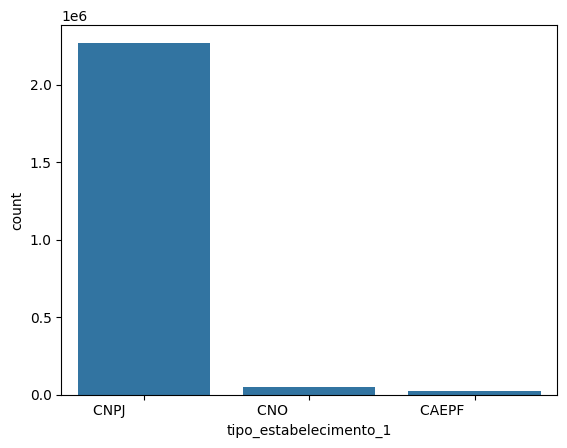

In [20]:
print(df_centrooeste_company["tipo_estabelecimento_1"].unique())
sns.countplot(x = df_centrooeste_company["tipo_estabelecimento_1"])
plt.show()

Como podemos ver, o tipo de estabelecimento predominante na base é CNPJ. De fato, parece razoável removermos da base os demais títulos de empresa, de modo a forcarmos a análise exclusivamente em empresas representadas por um CNPJ.

In [21]:
df_centrooeste_company.head(2)

,cod_municipio,cod_municipio_trabalho,estado,cnae_atualizada,cnae_antiga,cnae_atualizada_granular,natureza_juridica,tamanho_estabelecimento,tipo_estabelecimento,tipo_estabelecimento_1,ibge_subsetor,simples_nacional,cadastro_especifico_inss,trabalho_local_da_sede,cnae_str,cnae_divisao,cnae_secao,natureza_juridica_str,natureza_juridica_primeiro_digito,setor_economico
0,500270,500270,Campo Grande,68226,70327,6822600,2062,4,1,CNPJ,19,9,1,1,6822600,68,L,2062,2,setor_privado
1,500270,500270,Campo Grande,2306,999,230600,2062,4,1,CNPJ,19,9,9,1,0230600,2,A,2062,2,setor_privado


### Vínculo

In [24]:
df_centrooeste_vinculo.head(2)

,ocupacao,tipo_vinculo,tipo_admissao,vinculo_ativo_3112,mes_admissao,mes_desligamento,motivo_desligamento,tempo_emprego,faixa_tempo_emprego,horas_semanais,faixa_hora_contratual,jornada_intermitente,jornada_parcial
0,514225,10,0,0,0,7,11,18.0,4,44,6,0,0
1,711210,10,0,0,0,9,11,15.0,4,99,99,0,0


In [34]:
# Agrupa as ocupações segundo a Classificação Brasileira de Ocupações (CBO)

# Garante os 6 dígitos
df_centrooeste_vinculo['cbo_str'] = df_centrooeste_vinculo['ocupacao'].astype(str).str.zfill(6)
# Pega o primeiro dígito
df_centrooeste_vinculo['ocupacao_cbo'] = df_centrooeste_vinculo['cbo_str'].str[0]

# Mapeamento dos números para classes (dicionário)
mapa_cbo = {
    '0': 'Militares_Policiais',
    '1': 'Diretores_Gerentes',
    '2': 'Profissionais_Nivel_Superior',
    '3': 'Tecnicos_Nivel_Medio',
    '4': 'Servicos_Administrativos',
    '5': 'Servicos_e_Vendas',
    '6': 'Agropecuaria',
    '7': 'Industria_Producao',
    '8': 'Industria_Producao', # 7 e 8 se misturam na indústria
    '9': 'Manutencao_Reparacao'
}

In [39]:
# Garante que a variável seja tratada como número para a comparação
df_centrooeste_vinculo['tipo_vinculo_num'] = pd.to_numeric(df_centrooeste_vinculo['tipo_vinculo'], errors = 'coerce')

# Listas com os códigos exatos do seu dicionário
clt_indeterminado = [10, 15, 20, 25]
prazo_determinado = [50, 55, 60, 65, 70, 75, 90, 95]
setor_publico = [30, 31, 35, 96, 97]

# Regras de roteamento
condicoes = [
    df_centrooeste_vinculo['tipo_vinculo_num'].isin(clt_indeterminado),
    df_centrooeste_vinculo['tipo_vinculo_num'].isin(prazo_determinado),
    df_centrooeste_vinculo['tipo_vinculo_num'].isin(setor_publico)
]

categorias = [
    'CLT_Indeterminado', # Contrato sem prazo para acabar
    'Prazo_Determinado', # Contrato com prazo determinado (temporários e aprendizes)
    'Setor_Publico' # Setor Público e Estatutários
]

# O que for 40, 80, -1 ou nulo cairá automaticamente em 'Outros'
df_centrooeste_vinculo['vinculo_agrupado'] = np.select(condicoes, categorias, default='Outros')

In [49]:
# 1. Garante que a coluna seja interpretada como numérica para evitar erros de tipagem ('1' vs 1)
df_centrooeste_vinculo['tipo_admissao_num'] = pd.to_numeric(df_centrooeste_vinculo['tipo_admissao'], errors='coerce')

# 2. Define as condições baseadas nos códigos do seu dicionário
condicoes = [
    df_centrooeste_vinculo['tipo_admissao_num'] == 0,           # Estoque (Não admitido no ano)
    df_centrooeste_vinculo['tipo_admissao_num'].isin([1, 2]),   # Primeiro Emprego e Reemprego
    df_centrooeste_vinculo['tipo_admissao_num'].isin([3, 4])    # Transferências com e sem ônus
]

# 3. Define os nomes das novas macrocategorias correspondentes
categorias = [
    'Estoque_Anos_Anteriores',
    'Admissoes_Mercado',
    'Transferencias_Internas'
]

# 4. Aplica a vetorização. Tudo que não for 0, 1, 2, 3 ou 4 (ou seja, de 5 a 10, -1 ou nulo) 
# cairá automaticamente no grupo 'Especiais_Outros'
df_centrooeste_vinculo['admissao_agrupada'] = np.select(condicoes, categorias, default='Especiais_Outros')

# 5. Otimização de Memória: Converte a coluna resultante para variável categórica.
# Em uma base de milhões de linhas, isso reduz o uso de memória dessa coluna em até 90%.
df_centrooeste_vinculo['admissao_agrupada'] = df_centrooeste_vinculo['admissao_agrupada'].astype('category')

In [66]:
# Substitui horas semanais registradas como 99 por np.nan para que seja mais fácil a remoção dessas observações em seguida
df_centrooeste_vinculo['horas_semanais'] = df_centrooeste_vinculo['horas_semanais'].replace(99, np.nan)

In [69]:
# Agrupa "jornada_intermitente" e "jornada_parcial" em uma única variável categórica

# Regras: Se for 1 na coluna Parcial, vira 'Parcial'. Se for 1 na Intermitente, vira 'Intermitente'.
# Se for 0 em ambas, é a linha de base ('Integral').
condicoes = [
    df_centrooeste_vinculo['jornada_parcial'] == 1,
    df_centrooeste_vinculo['jornada_intermitente'] == 1
]

categorias = [
    'Jornada_Parcial',
    'Jornada_Intermitente'
]

# Cria a variável consolidada
df_centrooeste_vinculo['regime_jornada'] = np.select(condicoes, categorias, default='Jornada_Integral')

In [71]:
df_centrooeste_vinculo.head(2)

,ocupacao,tipo_vinculo,tipo_admissao,vinculo_ativo_3112,mes_admissao,mes_desligamento,motivo_desligamento,tempo_emprego,faixa_tempo_emprego,horas_semanais,...,cbo_str,cbo_grande_grupo,Ocupacao_Macro,ocupacao_cbo,tipo_vinculo_num,Vinculo_Agrupado,vinculo_agrupado,tipo_admissao_num,admissao_agrupada,regime_jornada
0,514225,10,0,0,0,7,11,18.0,4,44.0,...,514225,5,5,5,10,CLT_Indeterminado,CLT_Indeterminado,0,Estoque_Anos_Anteriores,Jornada_Integral
1,711210,10,0,0,0,9,11,15.0,4,NaN,...,711210,7,7,7,10,CLT_Indeterminado,CLT_Indeterminado,0,Estoque_Anos_Anteriores,Jornada_Integral


In [77]:
df_centrooeste_vinculo["regime_jornada"]

0          Jornada_Integral
1          Jornada_Integral
2          Jornada_Integral
3          Jornada_Integral
4          Jornada_Integral
                 ...       
2339295    Jornada_Integral
2339296    Jornada_Integral
2339297    Jornada_Integral
2339298    Jornada_Integral
2339299    Jornada_Integral
Name: regime_jornada, Length: 2339300, dtype: object

In [78]:
df_centrooeste_vinculo["regime_jornada"].unique()

array(['Jornada_Integral', 'Jornada_Intermitente', 'Jornada_Parcial'],
      dtype=object)

In [52]:
df_centrooeste_vinculo.columns

Index(['ocupacao', 'tipo_vinculo', 'tipo_admissao', 'vinculo_ativo_3112',
       'mes_admissao', 'mes_desligamento', 'motivo_desligamento',
       'tempo_emprego', 'faixa_tempo_emprego', 'horas_semanais',
       'faixa_hora_contratual', 'jornada_intermitente', 'jornada_parcial',
       'cbo_str', 'cbo_grande_grupo', 'Ocupacao_Macro', 'ocupacao_cbo',
       'tipo_vinculo_num', 'Vinculo_Agrupado', 'vinculo_agrupado',
       'tipo_admissao_num', 'admissao_agrupada'],
      dtype='object')

In [62]:
df_centrooeste_vinculo["jornada_parcial"].unique()

array([0, 1])

In [82]:
# "deficiencia" já incluso em "tipo_deficiencia" e variável "ano_chegada" igual para todos os trabalhadores
df_centrooeste_demographic_filtered = df_centrooeste_demographic.loc[: , ["idade", "faixa_etaria", "sexo",
                                                                          "raca", "escolaridade", "nacionalidade",
                                                                          "tipo_deficiencia"]]
# "cod_municipio" e "cod_municipio_trabalho" representam muitos valores distintos e categóricos. Inviável para modelagem
# A natureza jurídica é muito granular. Agrupamos na classe geral da empresa a partir do seu código, extraindo o setor econômico
# ibge_subsetor consiste em uma categorização mais antiga da atividade da empresa. Removemos em prol do uso de cnae_secao
# simples_nacional removido pois todas as observações tem o mesmo valor 
# cadastro_especifico_inss tem forte relação com "tipo_estabelecimento_1" e já foi substituído. Desconsideramos
df_centrooeste_company_filtered = df_centrooeste_company.loc[:, ["estado", "cnae_secao", "setor_economico", "tamanho_estabelecimento",
                                                                 "tipo_estabelecimento_1", "trabalho_local_da_sede", "cnae_secao",
                                                                 "setor_economico"]]
# ocupacao tem muitas categorias. Sendo assim, substituimos pela classificação geral do trabalho segundo a CBO
# tipo_admissao foi agrupado em três grandes classes, sendo o estoque dos anos anteriores (admitido antes do ano atual),
# admissoes mercado (contratação clássica via processo seletivo), transferências internas (com e sem ônus) e casos especiais ou públicos
# Tendo o número de horas semanais, não temos a necessidade de considerar a faixa de horas contratuais
# Jornada parcial, intermitente ou integral reduzidas à variável regime_jornada
df_centrooeste_vinculo_filtered = df_centrooeste_vinculo.loc[:, ["ocupacao_cbo", "vinculo_agrupado", "admissao_agrupada",
                                                                 "mes_admissao", "motivo_desligamento", "tempo_emprego",
                                                                 "horas_semanais", "regime_jornada"]]
df_centrooeste_remuneracao
# df_centrooeste_desligamento
# df_centrooeste_geographic